Installs

In [291]:

%pip install matplotlib
%pip install pandas
%pip install openpyxl
%pip install numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Setup

In [292]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_excel('debts.xlsx')

def totalDebt(dataframe):
    sum = 0

    for paid in df.columns:
        for payee in df.index:
            sum += df.at[payee, paid]
    
    return round(sum, 2)

def totalPayments(dataframe):
    sum = 0
    
    for paid in df.columns:
        for payee in df.index:
            if df.at[payee, paid] != 0:
                sum += 1
    
    return sum


Cleaning functions

In [293]:
def nameRows(dataframe):
    dataframe = dataframe.rename(index=dataframe.loc[:,"Payees"])
    dataframe = dataframe.drop("Payees", axis="columns")
    return dataframe

def removeDefunctColumns(dataframe):
    # Remove 0 columns
    for paid in dataframe.columns:
        if (dataframe[paid] == 0).all():
            dataframe = dataframe.drop(paid, axis="columns")

    return dataframe

def removeDefunctRows(dataframe):
    # Remove 0 rows
    for payee in dataframe.index:
        if (dataframe.loc[payee] == 0).all():
            dataframe = dataframe.drop(payee, axis="rows")

    return dataframe

def removeFullyResolvedDebters(dataframe):
    # Remove 0 columns and rows
    return removeDefunctColumns(removeDefunctRows(dataframe))

def validateData(dataframe):
    for paid in dataframe.columns:
        for payee in dataframe.index:
            #print(dataframe.xs(payee)[paid])
            if float(dataframe.loc[payee, paid]) < 0.01:
                dataframe.loc[payee, paid] = 0
            else:
                dataframe.loc[payee, paid] = round(float(dataframe.xs(payee)[paid]), 2)
            """
            if str(dataframe.xs(payee)[paid]).isnumeric():
                # Round data down to 2dp
                dataframe.loc[payee, paid] = round(float(dataframe.xs(payee)[paid]), 2)
                #dataframe.xs(payee)[paid] = round(float(dataframe.xs(payee)[paid]), 2)
            else:
                # Remove non-numerical data
                dataframe.loc[payee, paid] = 0
            """

    return dataframe

def cleanData(dataframe):
    dataframe = nameRows(dataframe)
    dataframe = removeFullyResolvedDebters(dataframe)
    dataframe = validateData(dataframe)

    return dataframe

df = cleanData(df)
print(df)

           Person 1  Person 2  Person 3  Person 4  Person 5  Person 6  \
Person 1      20.12     96.43     66.15     82.47     90.83      1.35   
Person 2      60.15     64.89     98.65     23.53     17.51      6.24   
Person 3      27.47     31.69     97.89      8.18     13.36     44.16   
Person 4       0.77     45.23     81.03     10.94     22.68     28.16   
Person 5      59.22     99.55     34.19     40.65     60.11     50.16   
Person 6      50.88     61.40     99.71     69.12     10.78     76.48   
Person 7      10.57      8.69      2.00     47.31     54.01     33.47   
Person 8      25.87     26.19     80.73     66.65      3.08     28.46   
Person 9      90.16     75.92     94.60      4.66     98.98     76.33   
Person 10     20.34     85.42     46.96      3.74     26.58     95.82   
Person 11     90.05     43.72     23.54     13.03     67.95     46.60   
Person 12     22.86     19.60     32.85     65.18      7.78     19.02   
Person 13     54.23     29.44     18.44     71.68  

Transformative functions

In [294]:
# Rule 0 - no one can owe themselves money and no two people can each owe one another money

def removeSelfDebt(dataframe):
    # Remove any debt someone owes to themselves
    for paid in dataframe.columns:
        for payee in dataframe.index:
            if paid == payee:
                dataframe.loc[payee, paid] = 0

    return dataframe

def removeOneToOneDebt(dataframe):
    for paid in dataframe.columns:
        for dupe in dupes:
            for payee in dataframe.index:
                dataframe = removeOTODebtLogic(paid, dupe, payee, dataframe)
    
    return dataframe

def removeOTODebtLogic(paid, dupe, payee, dataframe):
    if paid != payee or paid == dupe or dupe == payee:
        return dataframe
    elif dataframe.loc[payee, dupe] >= dataframe.loc[dupe, paid]:
        excess = round(dataframe.loc[payee, dupe] - dataframe.loc[dupe, paid], 2)
        dataframe.loc[payee, dupe] = excess
        dataframe.loc[dupe, paid] = 0
    else:
        excess = round(dataframe.loc[dupe, paid] - dataframe.loc[payee, dupe], 2)
        dataframe.loc[payee, dupe] = 0
        dataframe.loc[dupe, paid] = excess
        
    
    return dataframe

# Rule 1 - distributive
"""
x and y owe a and b means:
suppose x owes a the least money of the four:
x pays a, xa - xa
x pays b, xb + xa
y pays a, ya + xa
y pays b, yb - xa 

This simplifies out a payment whilst maintaining the amounts owed
"""
def distributive(dataframe):
    for payee1 in dataframe.index:
        for payee2 in dataframe.index:
            for paid1 in dataframe.columns:
                for paid2 in dataframe.columns:
                    dataframe = distributiveLogic(payee1, payee2, paid1, paid2, dataframe)
                    
    for payee in dataframe.index:
        for paid in dataframe.columns:
            if dataframe.loc[payee, paid] < 0.01:
                dataframe.loc[payee, paid] = 0
    
    return dataframe

def distributiveLogic(payee1, payee2, paid1, paid2, dataframe):
    if payee1 == payee2 or paid1 == paid2:
        # If the payees or the payers are the same, do nothing
        return dataframe
    elif dataframe.loc[payee1, paid1] == 0 or dataframe.loc[payee2, paid1] == 0 or dataframe.loc[payee1, paid2] == 0 or dataframe.loc[payee2, paid2] == 0:
        # If one of the payers doesn't owe one of the payees, do nothing
        return dataframe
    
    minValue = round(min(dataframe.loc[payee1, paid1], dataframe.loc[payee2, paid1], dataframe.loc[payee1, paid2], dataframe.loc[payee2, paid2]), 2)
    
    if minValue == dataframe.loc[payee1, paid1] or minValue == dataframe.loc[payee2, paid2]:
        dataframe.loc[payee1, paid1] = round(dataframe.loc[payee1, paid1] - minValue, 2)
        dataframe.loc[payee1, paid2] = round(dataframe.loc[payee1, paid2] + minValue, 2)
        dataframe.loc[payee2, paid1] = round(dataframe.loc[payee2, paid1] + minValue, 2)
        dataframe.loc[payee2, paid2] = round(dataframe.loc[payee2, paid2] - minValue, 2)
    elif minValue == dataframe.loc[payee1, paid2] or minValue == dataframe.loc[payee2, paid1]:
        dataframe.loc[payee1, paid1] = round(dataframe.loc[payee1, paid1] + minValue, 2)
        dataframe.loc[payee1, paid2] = round(dataframe.loc[payee1, paid2] - minValue, 2)
        dataframe.loc[payee2, paid1] = round(dataframe.loc[payee2, paid1] - minValue, 2)
        dataframe.loc[payee2, paid2] = round(dataframe.loc[payee2, paid2] + minValue, 2)
    
    return dataframe

# Rule 2 - transitive
"""
x owes y and y owes z mean:
if x owes y more than y owes z:
x can pay z on y's behalf and pay the remainder of their debt to y

else (if x owes y less):
x can pay on z y's behalf and y can pay the remainder 
"""
def transitive(dataframe):
    for paid in dataframe.columns:
        for dupe in dupes:
            for payee in dataframe.index:
                dataframe = transitiveLogic(payee, dupe, paid, dataframe)
    
    return dataframe

def transitiveLogic(payee, dupe, paid, dataframe):
    if payee == dupe or dupe == paid or paid == payee:
        # If 2 of the people are the same, do nothing
        return dataframe
    elif dataframe.loc[payee, dupe] == 0 or dataframe.loc[dupe, paid] == 0:
        # If already simplified, do nothing
        return dataframe
    
    elif dataframe.loc[payee, dupe] >= dataframe.loc[dupe, paid]:
        covered = round(dataframe.loc[dupe, paid], 2)
        extra = round(dataframe.loc[payee, dupe] - dataframe.loc[dupe, paid], 2)
    elif dataframe.loc[payee, dupe] < dataframe.loc[dupe, paid]:
        covered = round(dataframe.loc[payee, dupe], 2)
        extra = 0
        
    dataframe.loc[payee, dupe] = extra
    dataframe.loc[payee, paid] = dataframe.loc[payee, paid] + covered
    dataframe.loc[dupe, paid] = dataframe.loc[dupe, paid] - covered
    
    return dataframe

dupes = list(set(df.columns) & set(df.index))

# Find initial total debt
initialDebt = totalDebt(df)
initialPayments = totalPayments(df)

df = removeSelfDebt(df)
lessSelfDebt = totalDebt(df)
iPLessSelfDebt = totalPayments(df)

df = removeOneToOneDebt(df)
lessOneToOneDebt = totalDebt(df)
iPLessOTOD = totalPayments(df)


df = transitive(df)
lessTransitive = totalDebt(df)
iPLessTransitive = totalPayments(df)

df = distributive(df)
lessDistributive = totalDebt(df)
iPLessDistributive = totalPayments(df)

Results

                                                                         Report                                 
We saved a total of 2352 transactions
Totalling to over £109384.34 in traded money
 
There were 50 self debt transactions, totalling £2435.33
There were 1225 one to one debt transactions, totalling £78500.24
The transitive checker saved 706 transactions, totalling £28448.77
The distributive checker saved an additional 371 transactions
 
The full matrix of simplified debts can be found in simplifiedDebts.xlsx


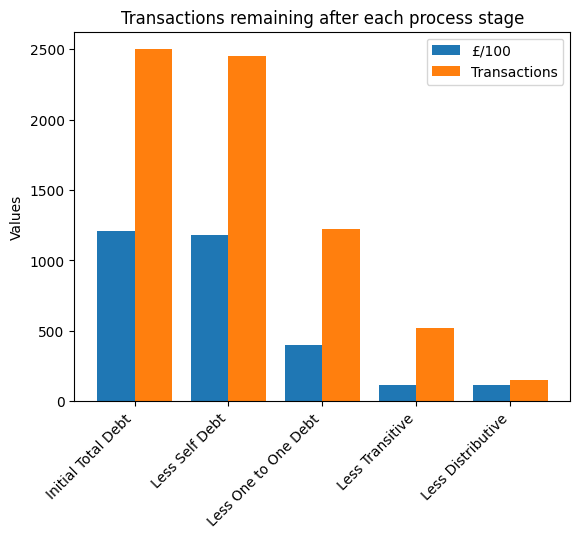

In [295]:
titles = ["Initial Total Debt", "Less Self Debt", "Less One to One Debt", "Less Transitive", "Less Distributive"]

values = [initialDebt, lessSelfDebt, lessOneToOneDebt, lessTransitive, lessDistributive]
values = [value // 100 for value in values]
values2 = [initialPayments, iPLessSelfDebt, iPLessOTOD, iPLessTransitive, iPLessDistributive]

print("========================================================================")
print("                                                                         Report                                 ")
print("========================================================================")
print("We saved a total of " + str(initialPayments - iPLessDistributive) + " transactions")
print("Totalling to over £" + str(initialDebt - lessDistributive) + " in traded money")
print(" ")
print("There were " + str(initialPayments - iPLessSelfDebt) + " self debt transactions, totalling £" + str(round(initialDebt - lessSelfDebt, 2)))
print("There were " + str(iPLessSelfDebt - iPLessOTOD) + " one to one debt transactions, totalling £" + str(lessSelfDebt - lessOneToOneDebt))
print("The transitive checker saved " + str(iPLessOTOD - iPLessTransitive) + " transactions, totalling £" + str(lessOneToOneDebt - lessTransitive))
print("The distributive checker saved an additional " + str(iPLessTransitive - iPLessDistributive) + " transactions")
print(" ")
print("The full matrix of simplified debts can be found in simplifiedDebts.xlsx")
print("========================================================================")

w, x = 0.4, np.arange(len(titles))

fig, ax = plt.subplots()
ax.bar(x - w/2, values, width=w, label='£/100')
ax.bar(x + w/2, values2, width=w, label='Transactions')

ax.set_xticks(x)
plt.xticks(rotation=45, ha='right')
ax.set_xticklabels(titles)
ax.set_ylabel('Values')
ax.set_title('Transactions remaining after each process stage')
ax.legend()

plt.show()

df = removeFullyResolvedDebters(df)
df = validateData(df)

df.to_excel("simplifiedDebts.xlsx", sheet_name="sheet1", index=True)